In [1]:
# 1. Install dependencies
!pip install -q transformers torch torchvision pillow pydantic matplotlib


In [2]:
# 2. Imports
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from typing import List
from pydantic import BaseModel
from transformers import ViTImageProcessor, ViTForImageClassification

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cuda


In [3]:
# 3. Load a pretrained, open-weight plant-disease ViT (no fine-tuning needed to start)
# If your demo crops/diseases don't overlap with this model's label set well enough,
# swap this for a fine-tune of google/vit-base-patch16-224 on the mohanty/PlantVillage
# dataset from Hugging Face Datasets -- but try the pretrained model first, it's free time saved.

MODEL_NAME = "wambugu71/crop_leaf_diseases_vit"

processor = ViTImageProcessor.from_pretrained(MODEL_NAME)
model = ViTForImageClassification.from_pretrained(MODEL_NAME, output_attentions=True)
model.eval()
model.to(device)

print("Loaded model with", model.config.num_labels, "classes")
print("Sample labels:", list(model.config.id2label.values())[:10])


preprocessor_config.json:   0%|          | 0.00/325 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.43k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/22.1M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loaded model with 13 classes
Sample labels: ['Corn___Common_Rust', 'Corn___Gray_Leaf_Spot', 'Wheat___Brown_Rust', 'Wheat___Healthy', 'Wheat___Yellow_Rust', 'Corn___Healthy', 'Invalid', 'Potato___Early_Blight', 'Potato___Healthy', 'Potato___Late_Blight']


In [4]:
# 4. Strict output schema for inter-agent communication (Day 2 orchestrator consumes this)

class VisionNodeOutput(BaseModel):
    disease_class: str
    confidence_score: float
    attention_matrix: List[List[float]]  # patch-grid attention weights (e.g. 14x14)
    is_ambiguous: bool

CONFIDENCE_THRESHOLD = 0.75


In [5]:
# 5. Attention rollout (Abnar & Zuidema, 2020) -- combines attention across all
# transformer layers into a single map showing which image patches the model
# actually looked at. This is our XAI signal for the Vision Node.

def attention_rollout(attentions):
    """attentions: tuple of (batch, heads, tokens, tokens) tensors, one per layer.
    Returns (batch, tokens, tokens) rolled-out attention.
    """
    tokens = attentions[0].size(-1)
    result = torch.eye(tokens, device=attentions[0].device).unsqueeze(0)
    for attn in attentions:
        attn_avg = attn.mean(dim=1)  # average over attention heads
        attn_avg = attn_avg + torch.eye(tokens, device=attn_avg.device)  # residual connection
        attn_avg = attn_avg / attn_avg.sum(dim=-1, keepdim=True)
        result = torch.matmul(attn_avg, result)
    return result


In [6]:
# 6. Main inference function -- this is the Vision Node's public interface

def run_vision_node(image: Image.Image) -> VisionNodeOutput:
    inputs = processor(images=image, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.softmax(outputs.logits, dim=-1)[0]
    pred_idx = int(torch.argmax(probs))
    confidence = float(probs[pred_idx])
    label = model.config.id2label[pred_idx]

    rolled = attention_rollout(outputs.attentions)
    cls_to_patches = rolled[0, 0, 1:]  # CLS token's attention to every patch token
    grid_size = int(len(cls_to_patches) ** 0.5)
    attn_grid = cls_to_patches.reshape(grid_size, grid_size).cpu().numpy()
    attn_grid = (attn_grid - attn_grid.min()) / (attn_grid.max() - attn_grid.min() + 1e-8)

    return VisionNodeOutput(
        disease_class=label,
        confidence_score=round(confidence, 4),
        attention_matrix=attn_grid.tolist(),
        is_ambiguous=confidence < CONFIDENCE_THRESHOLD,
    )


In [7]:
# 7. Heatmap visualization -- overlay the rolled attention map on the original image
# This is the "leaf attention map" side of your day-3 judge hook.

def visualize_attention(image: Image.Image, result: VisionNodeOutput, save_path=None):
    attn = np.array(result.attention_matrix)
    attn_resized = np.array(
        Image.fromarray((attn * 255).astype(np.uint8)).resize(image.size, Image.BICUBIC)
    ) / 255.0

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(image)
    axes[0].set_title("Original Leaf")
    axes[0].axis("off")

    axes[1].imshow(attn_resized, cmap="jet")
    axes[1].set_title("Attention Rollout")
    axes[1].axis("off")

    axes[2].imshow(image)
    axes[2].imshow(attn_resized, cmap="jet", alpha=0.5)
    axes[2].set_title(f"{result.disease_class} ({result.confidence_score:.1%})")
    axes[2].axis("off")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


Test

In [12]:
# 8a. Upload an image in Colab
from google.colab import files
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
image = Image.open(image_path).convert("RGB")


Saving 2.jpg to 2.jpg


In [13]:
# 8b. Run the Vision Node
result = run_vision_node(image)
print(result.model_dump_json(indent=2))

if result.is_ambiguous:
    print("\n>>> HITL GATE: confidence below threshold -- route to agronomist review, do NOT auto-prescribe.")


{
  "disease_class": "Potato___Early_Blight",
  "confidence_score": 0.9702,
  "attention_matrix": [
    [
      0.5623862743377686,
      0.4177868068218231,
      0.5790885090827942,
      0.5210849046707153,
      0.42961326241493225,
      0.5619196891784668,
      0.3307371437549591,
      0.15565894544124603,
      0.3126777410507202,
      0.48815223574638367,
      0.5875812768936157,
      0.6476070284843445,
      0.8603323698043823,
      0.9999979138374329
    ],
    [
      0.28079673647880554,
      0.2966509461402893,
      0.2559279501438141,
      0.12201788276433945,
      0.26680341362953186,
      0.37183812260627747,
      0.37077057361602783,
      0.05470287427306175,
      0.07918204367160797,
      0.11278638243675232,
      0.3202512860298157,
      0.4110864996910095,
      0.32609185576438904,
      0.4824732840061188
    ],
    [
      0.23048685491085052,
      0.6035011410713196,
      0.27121296525001526,
      0.21162356436252594,
      0.347394824028015

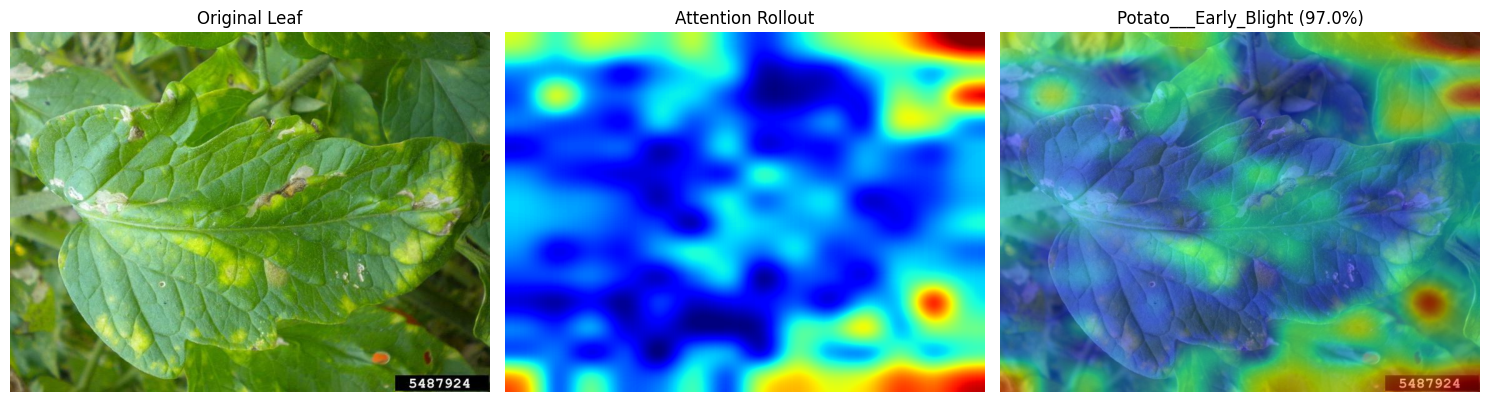

In [14]:
# 8c. Visualize
visualize_attention(image, result, save_path="vision_node_heatmap.png")


In [16]:
import json

with open("vision_node_output.json", "w") as f:
    json.dump(result.model_dump(), f, indent=2)

print("Saved vision_node_output.json -- feed this into the orchestrator's state graph.")


Saved vision_node_output.json -- feed this into the orchestrator's state graph.
